## 🏠 Boston House Price Prediction ###

### This notebook demonstrates the development and comparison of regression models to predict housing prices in Boston based on various socio-economic and geographic features.

### Description 
This dataset contains information about housing prices in Boston and is often used for regression analysis and predictive modeling. The dataset is based on the classic Boston Housing dataset, which is frequently used as a benchmark in machine learning.

## Attributes:

1.) **CRIM** (Per Capita Crime Rate): The per capita crime rate in the neighborhood.

2.) **ZN** (Proportion of Residential Land Zoned for Large Lots): The proportion of residential land zoned for lots over 25,000 sq. ft.

3.) **INDUS** (Proportion of Non-Retail Business Acres): The proportion of non-retail business acres per town.

4.) **CHAS** (Charles River Dummy Variable): A binary variable indicating whether the Charles River bounds the tract (1 if bounded, 0 otherwise).

5.) **NOX** (Nitric Oxides Concentration): Nitric oxides concentration (parts per 10 million).

6.) **RM** (Average Number of Rooms per Dwelling): The average number of rooms per dwelling.

7.) **AGE** (Proportion of Owner-Occupied Units Built Prior to 1940): The proportion of owner-occupied units built prior to 1940.

8.) **DIS** (Weighted Distances to Employment Centers): Weighted distances to five Boston employment centers.

9.) **RAD** (Index of Accessibility to Radial Highways): An index representing accessibility to radial highways.

10.) **TAX** (Full-Value Property Tax Rate per $10,000): The full-value property tax rate per $10,000.

11.) **PTRATIO** (Pupil-Teacher Ratio): The pupil-teacher ratio by town.

12.) **B** (1000(Bk - 0.63)^2 where Bk is the Proportion of Black Residents): A measure of the proportion of Black residents adjusted for an offset.

13.) **LSTAT** (Percentage of Lower Status of the Population): The percentage of lower-status residents in the population.

14.) **MEDV** (Median Value of Owner-Occupied Homes): The median value of owner-occupied homes in $1000s (Target Variable).


To Predict the median value of owner-occupied homes (MEDV) based on various features to gain insights into factors influencing housing prices.



## Importing libraries

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [8]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


##### There are no duplicates and missing values in the dataset

### Checking correlation of various variables with each other and analyzing their impact on the output variable , i.e , medv.

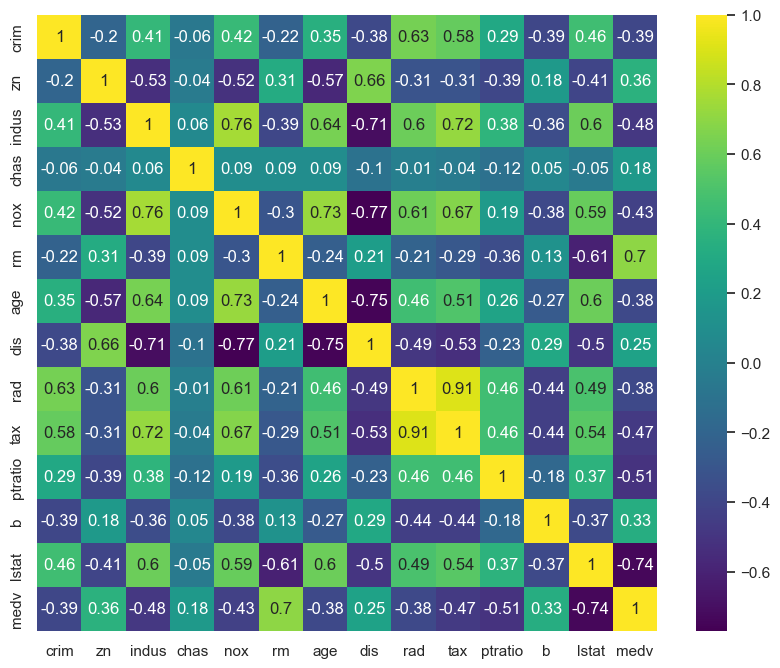

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr().round(2),annot=True,cmap='viridis') 
plt.show()

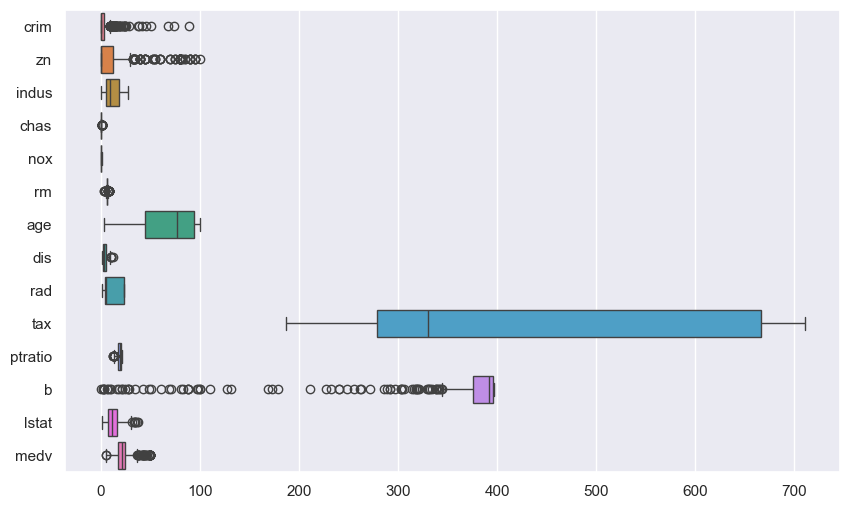

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, orient='h')
plt.show()

In [11]:
for i in df.columns:
    print("********************************************************************************************")
    print(i)
    print(set(df[i].tolist()))

********************************************************************************************
crim
{0.15876, 0.08826, 2.36862, 2.33099, 4.0974, 1.27346, 0.65665, 0.12744, 1.20742, 2.37934, 1.15172, 2.3004, 8.98296, 5.20177, 13.5222, 6.53876, 9.2323, 8.26725, 11.1081, 18.4982, 19.6091, 15.288, 17.8667, 23.6482, 15.8744, 20.0849, 24.3938, 22.5971, 25.0461, 24.8017, 28.6558, 25.9406, 0.07165, 0.1029, 37.6619, 38.3518, 41.5292, 45.7461, 9.91655, 51.1358, 11.5779, 0.08873, 0.6147, 0.09178, 0.09849, 0.06724, 0.05023, 67.9208, 13.6781, 73.5341, 15.1772, 0.05497, 4.55587, 4.03841, 88.9762, 5.70818, 0.11747, 0.07151, 0.11069, 0.04819, 0.02731, 0.09164, 0.06588, 0.07022, 0.29819, 0.09103, 0.06466, 0.26938, 0.10574, 0.03768, 0.0187, 0.07503, 0.03578, 0.06642, 0.13117, 0.18159, 1.6566, 14.4383, 0.04981, 0.0351, 4.87141, 0.12329, 7.75223, 0.08221, 0.04113, 0.57529, 0.75026, 0.84054, 0.12932, 1.41385, 0.537, 0.33045, 0.55007, 2.37857, 0.51183, 4.81213, 0.09068, 7.36711, 9.59571, 0.03306, 0.49298, 3.6

In [12]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.61,8.60,0.01,0.08,0.26,3.68,88.98
zn,506.0,11.36,23.32,0.00,0.00,0.00,12.50,100.00
indus,506.0,11.14,6.86,0.46,5.19,9.69,18.10,27.74
chas,506.0,0.07,0.25,0.00,0.00,0.00,0.00,1.00
nox,506.0,0.55,0.12,0.38,0.45,0.54,0.62,0.87
rm,506.0,6.28,0.70,3.56,5.89,6.21,6.62,8.78
age,506.0,68.57,28.15,2.90,45.02,77.50,94.07,100.00
dis,506.0,3.80,2.11,1.13,2.10,3.21,5.19,12.13
rad,506.0,9.55,8.71,1.00,4.00,5.00,24.00,24.00
tax,506.0,408.24,168.54,187.00,279.00,330.00,666.00,711.00


In [13]:
from scipy.stats import skew
skew_vals = df.skew().sort_values(ascending=False)
print(skew_vals.round(3))
print("\nPositively skewed (>0.5):", skew_vals[skew_vals > 0.5].index.tolist())
print("Negatively skewed (<-0.5):", skew_vals[skew_vals < -0.5].index.tolist())

crim       5.223
chas       3.406
zn         2.226
medv       1.108
dis        1.012
rad        1.005
lstat      0.906
nox        0.729
tax        0.670
rm         0.404
indus      0.295
age       -0.599
ptratio   -0.802
b         -2.890
dtype: float64

Positively skewed (>0.5): ['crim', 'chas', 'zn', 'medv', 'dis', 'rad', 'lstat', 'nox', 'tax']
Negatively skewed (<-0.5): ['age', 'ptratio', 'b']


#### chas  — binary variable (0/1), transformation not applicable
#### medv  — target variable, kept in original scale for interpretability
#### rm    — skew 0.297, below threshold, no treatment needed
#### indus — skew 0.295, below threshold, no treatment needed

In [14]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

cols_to_transform = ['crim', 'zn', 'dis', 'rad', 'lstat', 'nox', 'tax', 'ptratio', 'b', 'age']
df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

print("Skewness after Yeo-Johnson treatment:")
print(df.skew().round(3).sort_values())

Skewness after Yeo-Johnson treatment:
b         -1.909
age       -0.418
ptratio   -0.220
lstat     -0.018
rad        0.066
dis        0.067
tax        0.080
nox        0.098
indus      0.295
rm         0.404
crim       0.595
zn         1.072
medv       1.108
chas       3.406
dtype: float64


#### zn skewness remains at 1.070 after transformation
#### zn is zero-inflated — majority of values are exactly 0
#### No standard transformation can fully correct zero-inflated distributions

# Dividing the features into independent and dependent variable

In [15]:
x=df.drop('medv',axis=1)
y=df['medv']

In [16]:
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,-1.056151,1.605270,2.31,0,0.027165,6.575,-0.212875,0.443907,-2.314674,-0.556334,-1.408874,0.632757,-1.257099
1,-0.999901,-0.599954,7.07,0,-0.716093,6.421,0.314385,0.796950,-1.448933,-1.175887,-0.518692,0.632757,-0.334422
2,-0.999953,-0.599954,7.07,0,-0.716093,7.185,-0.363383,0.796950,-1.448933,-1.175887,-0.518692,0.502065,-1.543453
3,-0.986675,-0.599954,2.18,0,-0.851247,6.998,-0.891929,1.144611,-0.909551,-1.461842,-0.076443,0.559404,-1.934975
4,-0.894461,-0.599954,2.18,0,-0.851247,7.147,-0.608476,1.144611,-0.909551,-1.461842,-0.076443,0.632757,-1.161275


In [17]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

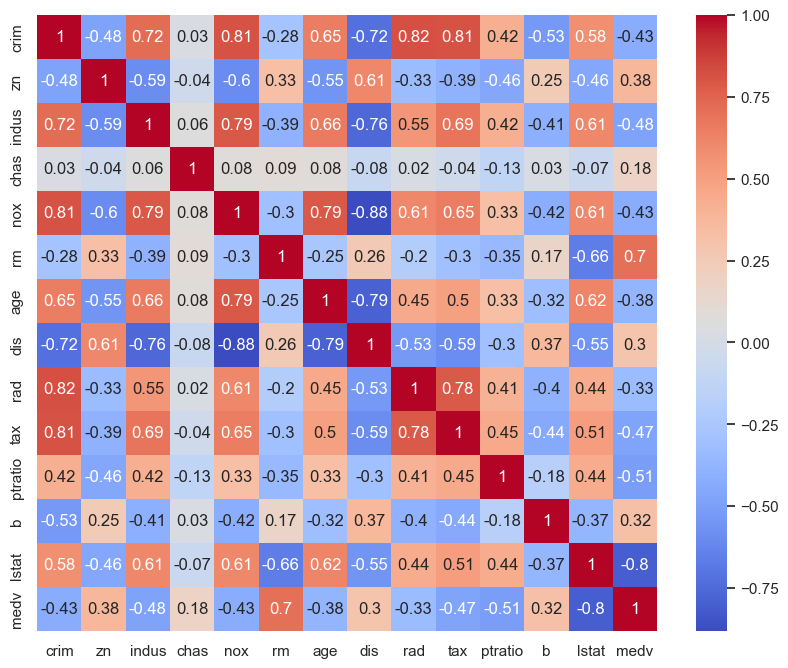

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr().round(2),annot=True,cmap='coolwarm') 
plt.show()

# Building the model 

### Splitting the data into train and test 

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2 , random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("Scaler fitted on:", list(scaler.feature_names_in_))

Scaler fitted on: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


In [22]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


# VIF

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif['Features'] = x_train.columns
vif['VIF']      = [variance_inflation_factor(x_train_scaled, i)
                   for i in range(x_train_scaled.shape[1])]
vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)
print("VIF — Before dropping:")
print(vif)

VIF — Before dropping:
   Features       VIF
0       nox  7.244002
1      crim  7.129948
2       dis  5.508446
3     indus  3.747933
4       tax  3.656644
5       rad  3.613632
6       age  3.475793
7     lstat  3.232177
8        rm  2.099497
9        zn  2.047274
10  ptratio  1.645283
11        b  1.440851
12     chas  1.088595


In [24]:
# Drop highest VIF column
high_vif_col = vif.iloc[0]['Features']
print(f'Dropping: {high_vif_col}')

# Drop from both train and test
x_train = pd.DataFrame(x_train_scaled, columns=x_train.columns).drop(columns=[high_vif_col])
x_test  = pd.DataFrame(x_test_scaled,  columns=x_test.columns).drop(columns=[high_vif_col])

print(f'x_train shape after drop: {x_train.shape}')
print(f'x_test  shape after drop: {x_test.shape}')

Dropping: nox
x_train shape after drop: (404, 12)
x_test  shape after drop: (102, 12)


In [25]:
# Second VIF check
vif2 = pd.DataFrame()
vif2['Features'] = x_train.columns
vif2['VIF'] = [variance_inflation_factor(x_train.values, i) 
               for i in range(x_train.shape[1])]
vif2 = vif2.sort_values('VIF', ascending=False).reset_index(drop=True)
print("\nVIF — After dropping:")
print(vif2)


VIF — After dropping:
   Features       VIF
0      crim  6.504626
1       dis  4.450245
2       tax  3.654721
3       rad  3.611585
4     indus  3.604066
5       age  3.330035
6     lstat  3.192657
7        rm  2.098858
8        zn  2.001204
9   ptratio  1.611971
10        b  1.438785
11     chas  1.086910


In [26]:
# crim still has VIF 6.5 — drop it as well
x_train = x_train.drop(columns=['crim'])
x_test  = x_test.drop(columns=['crim'])

# Final VIF check
vif3 = pd.DataFrame()
vif3['Features'] = x_train.columns
vif3['VIF'] = [variance_inflation_factor(x_train.values, i) 
               for i in range(x_train.shape[1])]
vif3 = vif3.sort_values('VIF', ascending=False).reset_index(drop=True)
print("VIF — Final:")
print(vif3)
print(f'\nFinal x_train shape: {x_train.shape}')
print(f'Final x_test  shape: {x_test.shape}')

VIF — Final:
   Features       VIF
0       dis  4.301251
1     indus  3.518687
2       tax  3.324984
3       age  3.249471
4     lstat  3.180808
5       rad  2.690718
6        rm  2.097051
7        zn  1.998514
8   ptratio  1.611456
9         b  1.331400
10     chas  1.085402

Final x_train shape: (404, 11)
Final x_test  shape: (102, 11)


In [27]:
vif3 = pd.DataFrame()
vif3['Features'] = x_train.columns
vif3['VIF']      = [variance_inflation_factor(x_train.values, i)
                    for i in range(x_train.shape[1])]
vif3 = vif3.sort_values('VIF', ascending=False).reset_index(drop=True)
print("VIF — Final (all should be < 5):")
print(vif3)
print(f'\nFinal columns: {list(x_train.columns)}')

VIF — Final (all should be < 5):
   Features       VIF
0       dis  4.301251
1     indus  3.518687
2       tax  3.324984
3       age  3.249471
4     lstat  3.180808
5       rad  2.690718
6        rm  2.097051
7        zn  1.998514
8   ptratio  1.611456
9         b  1.331400
10     chas  1.085402

Final columns: ['zn', 'indus', 'chas', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


In [28]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

            Methods used  R2_score        MSE      RMSE       MAE      MAPE
0       LinearRegression  0.716419  20.796066  4.560270  2.921356  0.151800
1                  Ridge  0.716430  20.795291  4.560185  2.920777  0.151772
2                  Lasso  0.715568  20.858461  4.567106  2.886074  0.149775
3             ElasticNet  0.715081  20.894202  4.571018  2.821899  0.146466
4  DecisionTreeRegressor  0.733002  19.580000  4.424929  2.945098  0.164283
5  RandomForestRegressor  0.856130  10.550496  3.248153  2.261931  0.125543
6           XGBRegressor  0.861865  10.129997  3.182766  2.197734  0.130476
7    KNeighborsRegressor  0.739244  19.122200  4.372894  2.524902  0.128078
8                    SVR  0.704544  21.666929  4.654775  2.550344  0.134147
9        VotingRegressor  0.824965  12.835971  3.582732  2.193775  0.114078
Axes(0.125,0.11;0.775x0.77)


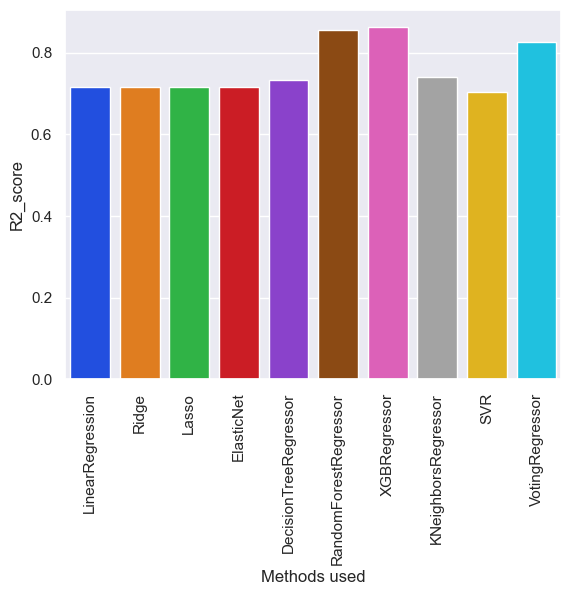

In [30]:
LR=LinearRegression()
LR.fit(x_train , y_train)
y_pred_test=LR.predict(x_test)
r2_LR=r2_score(y_test,y_pred_test)
mse_LR = mean_squared_error(y_test, y_pred_test)
rmse_LR = np.sqrt(mse_LR)
mae_LR = mean_absolute_error(y_test, y_pred_test)
mape_LR = mean_absolute_percentage_error(y_test, y_pred_test)

Rid=Ridge(alpha=0.1)
Rid.fit(x_train , y_train)
y_pred_test=Rid.predict(x_test)
r2_Rid=r2_score(y_test,y_pred_test)
mse_Rid = mean_squared_error(y_test, y_pred_test)
rmse_Rid = np.sqrt(mse_Rid)
mae_Rid = mean_absolute_error(y_test, y_pred_test)
mape_Rid = mean_absolute_percentage_error(y_test, y_pred_test)


Las=Lasso(alpha=0.1)
Las.fit(x_train , y_train)
y_pred_test=Las.predict(x_test)
r2_Las=r2_score(y_test,y_pred_test)
mse_Las = mean_squared_error(y_test, y_pred_test)
rmse_Las = np.sqrt(mse_Las)
mae_Las = mean_absolute_error(y_test, y_pred_test)
mape_Las = mean_absolute_percentage_error(y_test, y_pred_test)

Elastic=ElasticNet(alpha=0.1,l1_ratio=0.5,)
Elastic.fit(x_train , y_train)
y_pred_test=Elastic.predict(x_test)
r2_Elastic=r2_score(y_test,y_pred_test)
mse_Elastic = mean_squared_error(y_test, y_pred_test)
rmse_Elastic = np.sqrt(mse_Elastic)
mae_Elastic = mean_absolute_error(y_test, y_pred_test)
mape_Elastic = mean_absolute_percentage_error(y_test, y_pred_test)


dtree=DecisionTreeRegressor(random_state=42)
dtree.fit(x_train , y_train)
y_pred_test=dtree.predict(x_test)
r2_dtree=r2_score(y_test,y_pred_test)
mse_dtree = mean_squared_error(y_test, y_pred_test)
rmse_dtree = np.sqrt(mse_dtree)
mae_dtree = mean_absolute_error(y_test, y_pred_test)
mape_dtree = mean_absolute_percentage_error(y_test, y_pred_test)


rfc=RandomForestRegressor(random_state=42)
rfc.fit(x_train , y_train)
y_pred_test=rfc.predict(x_test)
r2_rfc=r2_score(y_test,y_pred_test)
mse_rfc = mean_squared_error(y_test, y_pred_test)
rmse_rfc = np.sqrt(mse_rfc)
mae_rfc = mean_absolute_error(y_test, y_pred_test)
mape_rfc = mean_absolute_percentage_error(y_test, y_pred_test)

xgb=XGBRegressor()
xgb.fit(x_train , y_train)
y_pred_test=xgb.predict(x_test)
r2_xgb=r2_score(y_test,y_pred_test)
mse_xgb = mean_squared_error(y_test, y_pred_test)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_test)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_test)

KNC=KNeighborsRegressor()
KNC.fit(x_train , y_train)
y_pred_test=KNC.predict(x_test)
r2_KNC=r2_score(y_test,y_pred_test)
mse_KNC = mean_squared_error(y_test, y_pred_test)
rmse_KNC = np.sqrt(mse_KNC)
mae_KNC = mean_absolute_error(y_test, y_pred_test)
mape_KNC = mean_absolute_percentage_error(y_test, y_pred_test)

svm=SVR()
svm.fit(x_train , y_train)
y_pred_test=svm.predict(x_test)
r2_svm=r2_score(y_test,y_pred_test)
mse_svm = mean_squared_error(y_test, y_pred_test)
rmse_svm = np.sqrt(mse_svm)
mae_svm = mean_absolute_error(y_test, y_pred_test)
mape_svm = mean_absolute_percentage_error(y_test, y_pred_test)

voc=VotingRegressor(estimators=[('LR',LR),('Rid',Rid),('Las',Las),('elastic',Elastic),('dtree',dtree),('rfc',rfc),('xgb',xgb),('KNC',KNC),('svm',svm)])
voc.fit(x_train , y_train)
y_pred_train=voc.predict(x_train)
y_pred_test=voc.predict(x_test)
r2_voc=r2_score(y_test,y_pred_test)
mse_voc = mean_squared_error(y_test, y_pred_test)
rmse_voc = np.sqrt(mse_voc)
mae_voc = mean_absolute_error(y_test, y_pred_test)
mape_voc = mean_absolute_percentage_error(y_test, y_pred_test)

list1=['LinearRegression','Ridge','Lasso','ElasticNet','DecisionTreeRegressor','RandomForestRegressor','XGBRegressor','KNeighborsRegressor','SVR','VotingRegressor']
list2=[r2_LR,r2_Rid,r2_Las,r2_Elastic,r2_dtree,r2_rfc,r2_xgb,r2_KNC,r2_svm,r2_voc]
list3=[mse_LR,mse_Rid,mse_Las,mse_Elastic,mse_dtree,mse_rfc,mse_xgb,mse_KNC,mse_svm,mse_voc]
list4=[rmse_LR,rmse_Rid,rmse_Las,rmse_Elastic,rmse_dtree,rmse_rfc,rmse_xgb,rmse_KNC,rmse_svm,rmse_voc]
list5=[mae_LR,mae_Rid,mae_Las,mae_Elastic,mae_dtree,mae_rfc,mae_xgb,mae_KNC,mae_svm,mae_voc]
list6=[mape_LR,mape_Rid,mape_Las,mape_Elastic,mape_dtree,mape_rfc,mape_xgb,mape_KNC,mape_svm,mape_voc]

df_accuracy=pd.DataFrame({'Methods used':list1 , 'R2_score':list2 , "MSE":list3,"RMSE":list4,"MAE":list5,"MAPE":list6})
print(df_accuracy)

unique_colors = sns.color_palette("bright", len(df_accuracy))

chart=sns.barplot(x="Methods used" , y="R2_score" , data=df_accuracy,palette=unique_colors)
chart.set_xticklabels(chart.get_xticklabels(),rotation=90)
print(chart)

# Observations

In [31]:
xgb = XGBRegressor(
    n_estimators  = 200,
    max_depth     = 3,
    learning_rate = 0.1,   
    subsample     = 0.8,   
    random_state  = 42,
    verbosity     = 0
)

xgb.fit(x_train, y_train)

r2_xgb_train = r2_score(y_train, xgb.predict(x_train))
r2_xgb_test  = r2_score(y_test,  xgb.predict(x_test))

print('Train R² Score :', round(r2_xgb_train, 4))
print('Test R²  Score :', round(r2_xgb_test,  4))
print('Overfit Gap    :', round(r2_xgb_train - r2_xgb_test, 4))

Train R² Score : 0.9871
Test R²  Score : 0.8878
Overfit Gap    : 0.0993


Final XGBoost params: n_estimators=200, max_depth=3, 
learning_rate=0.1, subsample=0.8

Train R² : 0.987
Test R²  : 0.888
Gap      : 0.099

Note: Overfitting gap of ~10% is expected on a small dataset of 506 rows.
The model generalises well with Test R² of 0.888.
Reducing n_estimators lowers the gap but also reduces Test R² — 
0.888 represents the best generalisation performance achieved.

In [32]:
from sklearn.model_selection import cross_val_score
import numpy as np

training = cross_val_score(xgb, x_train, y_train, cv=10, scoring='r2')

print("CV R² Scores     :", training.round(4))
print("Mean CV R² Score :", round(training.mean(), 4))
print("Std Dev          :", round(training.std(), 4))

CV R² Scores     : [0.8082 0.9095 0.8792 0.6342 0.865  0.8986 0.9103 0.889  0.9198 0.6668]
Mean CV R² Score : 0.8381
Std Dev          : 0.0987


In [34]:
from joblib import dump
from sklearn.preprocessing import StandardScaler

# Re-fit scaler on final columns after VIF dropping
scaler_final = StandardScaler()
scaler_final.fit(x_train)

dump(scaler_final, 'scaler.joblib')
dump(xgb,          'model_XGBoost.joblib')
dump(df_accuracy,  'model_metrics.pkl')

print("Saved successfully.")
print("Scaler expects:", list(scaler_final.feature_names_in_))
print("Columns count :", len(scaler_final.feature_names_in_))

Saved successfully.
Scaler expects: ['zn', 'indus', 'chas', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Columns count : 11


In [35]:
df_accuracy.to_csv("model_metrics.csv", index=False)
print("model_metrics.csv saved.")

model_metrics.csv saved.
